# M7 — Second SAE Absorption Case Beyond Georgia: Profession Is-A Hierarchy + Homograph Scan

This demo accompanies the experiment **"M7: Second SAE Absorption Case Beyond Georgia — Profession Is-A Hierarchy + Homograph Scan."**

**Research question.** Sparse-autoencoder (SAE) latents suffer from *feature absorption*: a general
"parent" latent (e.g. *country*) is suppressed on a polysemous token while a hidden "specialist"
latent silently takes over. The iter-4 result found exactly one clean non-spelling absorption case
(the homograph **Georgia** — the U.S. state vs. the country), effectively **n=1** (1–2 counting the
descriptive **Jordan**). This experiment asks whether that result **corroborates on a second case**.

It runs three parts on the **frozen** Gemma-2-2b / Gemma-Scope `layer_12/width_16k` JumpReLU SAE:

- **Part 1 (new science).** Is absorption a property of a clean *is-a* hierarchy? Test the
  `bias_in_bios` **profession** hierarchy (a general *occupation* parent vs. 28 specific professions)
  for a suppressed-parent + mutually-exclusive-specialist signature.
- **Part 2 (homograph scan).** Re-run the iter-4 taxonomic pipeline and regenerate the
  *homograph × absorption-type* cross-tab over all 52 countries; scan entity surfaces for any new case.
- **Part 3 (Jordan beside Georgia).** A single side-by-side selection table (Georgia *eligible* /
  Jordan *descriptive* / United States *co-firing*) with n and AUC-diff CIs.

The two-track **set-cover unit** (parent + absorber specialist) is compared against **raw-SAE
baselines** (anchor, g = top-20 marginal-attr, h = count-matched, S_rec/S_prec/S_mag label-free
selectors, RE-k-anchored) and a **non-SAE dense difference-of-means probe**.

> **Verdict (the expected, publishable honest negative): `absorption_remains_narrow`.** Absorption is
> specific to *suppressed-parent homograph polysemy*, **not** a general taxonomic phenomenon.

---

### What this notebook runs

The heavy step in the original `method.py` — loading Gemma-2-2b and whole-text encoding ~19k texts
through the SAE on a GPU — is **precomputed and cached** (the paper reports per-token FVU = 0.173,
mean L0 = 76.9). Re-runs are GPU-free. This demo therefore loads the **precomputed analysis output**
(`method_out.json`) and **re-derives the headline tables and metrics** from it, including a live
recomputation of per-detector **recall** from the per-row predictions that reconstructs the
*parent recall hole* — the very signature of feature absorption. It also runs the original
verdict/honest-negative logic (`build_verdict`, `honest_negatives`) verbatim.

In [1]:
# --- Install dependencies (Colab-safe) ---
# On Colab: numpy/pandas/matplotlib are pre-installed -> do NOT reinstall (corrupts C extensions).
# Locally: install at Colab's exact versions so the environment matches Colab.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# (No non-Colab packages are needed for this analysis demo.)

if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "pandas==2.2.2", "matplotlib==3.10.0")
print("dependencies ready")

dependencies ready



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
# From the original method.py the demo keeps the lightweight, analysis-only imports.
# (The full pipeline additionally does `import torch`, `import engine as eng`,
#  `import profession_absorption as pa` for the GPU whole-text encode + SAE — that step is
#  precomputed/cached here, so those heavy imports are not needed to reproduce the analysis.)
import json, os
import numpy as np
from collections import defaultdict

# Notebook-only helpers for tables and plots
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.0.2 | pandas 2.2.2


In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab compatibility) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/experiment-4/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
# --- Load the precomputed method output (curated demo subset) ---
data = load_data()

meta = data["metadata"]
prof = meta["per_family"]["professions"]   # Part 1 result (profession is-a hierarchy)
tax  = meta["per_family"]["taxonomic"]     # Parts 2-3 result (homograph scan + side-by-side)

print("method:", meta["method_name"][:90], "...")
print("overall verdict :", meta["verdict"])
print("professions verdict:", prof["professions_verdict"])
print("SAE:", meta["sae"]["release"], meta["sae"]["sae_id"])
print("datasets in demo:", [(d["dataset"], len(d["examples"])) for d in data["datasets"]])

method: M7 iter-5 — SECOND polysemy/absorption case beyond Georgia: bias_in_bios profession is-a h ...
overall verdict : absorption_remains_narrow
professions verdict: uniform_high_parent_recall_no_absorption
SAE: gemma-scope-2b-pt-res-canonical layer_12/width_16k/canonical
datasets in demo: [('taxonomic_sidebyside', 102)]


## Configuration

All tunable parameters live here. They default to small values for a fast demo run; comments give the
full-run values used to produce the paper's `method_out.json`. The heavy SAE-encode parameters
(`cap_per_profession=500`, `n_neg=5000`, bootstrap `B=10,000`) are read back from the precomputed
metadata for display — the demo re-derives results from the cached output rather than re-encoding.

In [5]:
# --- Config (start minimal; scale up as desired) ---

# Detectors compared side-by-side (unit = two-track set-cover; rest are baselines).
DETECTORS = ["unit", "anchor", "g", "h", "dense_probe", "rek", "S_rec", "S_prec", "S_mag"]

# Country slices analysed in Part 3 (Georgia eligible / Jordan descriptive / United States co-firing).
COUNTRIES = ["Georgia", "Jordan", "United States"]

# How many per-row examples per country to use in the LIVE recall recomputation.
# Minimal demo value; set to None to use ALL examples available in the demo subset (~34/country).
# (Original full run analysed every diagnostic row: 150 Georgia / 124 Jordan / 150 United States.)
N_PER_COUNTRY = None        # was: 5 (smoke);  full demo subset = all (~34/country)

# absorption_type rule (from the paper's thresholds): a suppressed-parent hole AND a
# mutually-exclusive specialist.  parent_hole > HOLE_THRESHOLD AND firing-Jaccard < JACCARD_MAX.
HOLE_THRESHOLD = 0.5
JACCARD_MAX = meta["thresholds"]["jaccard_max"]   # 0.10

print("DETECTORS      :", DETECTORS)
print("COUNTRIES      :", COUNTRIES)
print("N_PER_COUNTRY  :", N_PER_COUNTRY)
print("HOLE_THRESHOLD :", HOLE_THRESHOLD, "| JACCARD_MAX:", JACCARD_MAX)
print("(precomputed encode: cap/profession=%s, n_neg=%s, bootstrap B=%s)"
      % (meta["thresholds"]["cap_per_profession"], prof["n_neg"], meta["stats"]["bootstrap_B_auc"]))

DETECTORS      : ['unit', 'anchor', 'g', 'h', 'dense_probe', 'rek', 'S_rec', 'S_prec', 'S_mag']
COUNTRIES      : ['Georgia', 'Jordan', 'United States']
N_PER_COUNTRY  : None
HOLE_THRESHOLD : 0.5 | JACCARD_MAX: 0.1
(precomputed encode: cap/profession=500, n_neg=5000, bootstrap B=10000)


## Part 1 — Profession is-a hierarchy: the 28-profession hole table

The headline deliverable. The corpus-only **parent** is `latent 12692` (a general
*biography/occupation* latent; held-out recall **0.973**, content-style precision 0.906). For every
one of the 28 professions we measure, on a held-out fold, the **parent recall hole** (= 1 − fraction
of that profession's bios on which the parent fires) and whether any mutually-exclusive **specialist**
latent fills it (firing-Jaccard with the parent < 0.10).

A profession shows the **absorption signature** only if `parent_hole > 0.5` **and** a specialist
exists with Jaccard `< 0.10` (`absorption_type = True`).

In [6]:
# --- Part 1: render the 28-profession hole table (held-out fold) ---
hole_table = prof["hole_table"]

rows = []
for p, e in hole_table.items():
    rows.append({
        "profession": p,
        "n": e["n"],
        "parent_recall": round(e["parent_recall"], 3),
        "parent_hole": round(e["parent_hole"], 3),
        "n_specialists": e["n_specialists"],
        "best_jaccard": (round(e["best_jaccard"], 4) if e["best_jaccard"] is not None else None),
        "absorption_type": e["absorption_type"],
    })
hole_df = pd.DataFrame(rows).sort_values("parent_hole", ascending=False).reset_index(drop=True)
print(hole_df.to_string(index=False))

max_hole = prof["max_parent_hole"]
n_abs_type = prof["n_absorption_type"]
print("\nmax parent hole : %.3f  (profession '%s')" % (max_hole, prof["max_parent_hole_profession"]))
print("parent recall range : %.3f - %.3f" % (hole_df["parent_recall"].min(), hole_df["parent_recall"].max()))
print("professions with absorption_type=True : %d / %d" % (n_abs_type, len(hole_table)))

       profession   n  parent_recall  parent_hole  n_specialists  best_jaccard  absorption_type
            model 250          0.884        0.116             14        0.0021            False
          teacher 250          0.936        0.064              0        1.0000            False
     chiropractor 250          0.944        0.056              0        1.0000            False
           rapper 193          0.948        0.052              0        1.0000            False
               dj 230          0.952        0.048              0        1.0000            False
        dietitian 250          0.964        0.036              0        1.0000            False
          dentist 250          0.964        0.036              3        0.0046            False
         comedian 250          0.968        0.032              1        0.0055            False
     photographer 250          0.968        0.032              0        1.0000            False
         attorney 250          0.976    

### Part 1 verdict — re-deriving the rule

The profession verdict follows directly from the hole table, using the exact branch logic from
`method.py`. With every parent recall in 0.88–1.00 (no suppressed hole) and 0 professions of
`absorption_type`, the rule lands on `uniform_high_parent_recall_no_absorption`: a general occupation
parent fires on essentially *all* professions, so there is **no hole for a specialist to fill** —
absorption does **not** generalise to a clean is-a hierarchy.

In [7]:
# --- Part 1: re-derive professions_verdict (mirrors method.py branch logic) ---
qualifying = prof["qualifying_professions"]
second_case_professions = prof["second_case_professions"]

if second_case_professions:
    professions_verdict = "second_case_found"
elif n_abs_type > 0:
    professions_verdict = "absorption_signature_without_setcover"   # holes+specialist but unit !> selectors
elif max_hole > 0.5:
    professions_verdict = "holes_without_mutually_exclusive_specialist"   # splitting, not absorption
else:
    professions_verdict = "uniform_high_parent_recall_no_absorption"   # the EXPECTED boundary-null

print("re-derived professions_verdict :", professions_verdict)
print("stored    professions_verdict  :", prof["professions_verdict"])
assert professions_verdict == prof["professions_verdict"], "verdict logic mismatch"
print("qualifying (eligible & absorption) professions:", qualifying or "[]  (none)")

re-derived professions_verdict : uniform_high_parent_recall_no_absorption
stored    professions_verdict  : uniform_high_parent_recall_no_absorption
qualifying (eligible & absorption) professions: []  (none)


### Part 1 baseline contrast — the largest-hole profession `model`

`model` has the largest (still small) hole, 0.116. As a **descriptive** check, the set-cover unit is
run one-vs-rest against the baselines. Because there is no absorption hole, the greedy search adds
**no** absorber and the "unit" degenerates to the bare parent — a general parent is a *poor* specific
class detector. The non-SAE dense difference-probe wins easily. `set_cover_established = False`: the
two-track method only helps when an absorption signature actually exists (contrast with Georgia, Part 3).

In [8]:
# --- Part 1: baseline AUCs on profession 'model' (one-vs-rest, DESCRIPTIVE) ---
model_sc = prof["setcover"]["model"]
auc_pt = model_sc["auc_point"]

auc_df = (pd.DataFrame({"detector": list(auc_pt.keys()),
                        "one_vs_rest_AUC": [round(v, 3) for v in auc_pt.values()]})
          .sort_values("one_vs_rest_AUC", ascending=False).reset_index(drop=True))
print(auc_df.to_string(index=False))
print("\nunit latents:", model_sc["unit"], "| n_absorbers:", model_sc["n_absorbers"])
print("set_cover_established:", model_sc["set_cover_established"])

     detector  one_vs_rest_AUC
  dense_probe            0.961
            h            0.632
            g            0.544
         unit            0.308
       anchor            0.308
rek_anch_mean            0.308
   S_rec_anch            0.308
  S_prec_anch            0.308
   S_mag_anch            0.308

unit latents: [12692] | n_absorbers: 0
set_cover_established: False


## Part 2 — Homograph scan: the absorption × homograph cross-tab

Re-running the iter-4 taxonomic pipeline reproduces it exactly. `absorption_type` (parent hole > 0.5
**and** specialist Jaccard < 0.10) is True for **exactly {Georgia, Jordan}** — both documented
homographs whose general *country* parent (`latent 3792`) is suppressed. The cross-tab confirms the
scoping claim: absorption sits in the *homograph × absorption* cell only.

In [9]:
# --- Part 2: homograph x absorption-type cross-tab ---
hc = tax["homograph_crosstab"]
print("counts:")
for cell, cnt in hc["counts"].items():
    members = hc["members"].get(cell, [])
    shown = ", ".join(members[:6]) + (" ..." if len(members) > 6 else "")
    print("  %-26s %3d   %s" % (cell, cnt, shown if members else "(none)"))

print("\nabsorption_type slices:", hc["absorption_type_slices"])
print("are exactly suppressed homographs:", hc["absorption_type_slices_are_exactly_suppressed_homographs"])

counts:
  homograph|absorption         2   Georgia, Jordan
  homograph|no_absorption      2   Chile, Turkey
  non_homograph|absorption     0   (none)
  non_homograph|no_absorption  48   Argentina, Australia, Austria, Belgium, Brazil, Canada ...

absorption_type slices: ['Georgia', 'Jordan']
are exactly suppressed homographs: True


### Entity-token scan

Group diagnostic country-mention surfaces (≥150 occurrences) by token and test the *country* parent's
recall-hole plus a mutually-exclusive specialist. The only `absorption_type` surface is **Georgia**
(Jordan's n = 124 < 150 falls below the inferential floor). **No new case** beyond Georgia/Jordan.
Honest coverage limit: the testbed labels per-*country*, not per-*city*, so non-country entity
absorption is untestable here — "no new case" is expected, not exhaustive.

In [10]:
# --- Part 2: entity-token scan summary ---
es = tax["entity_scan"]
print("surfaces tested (>=150 occurrences):", es["n_surfaces_tested"])
print("absorption_type surfaces           :",
      [r["surface"] for r in es["new_absorption_surfaces"]])
print("NEW case beyond Georgia/Jordan     :", es["new_case_beyond_known"] or "[]  (none)")

# surfaces_tested already includes the absorption_type surfaces (e.g. Georgia)
es_df = pd.DataFrame([{ "surface": r["surface"], "n": r["n"],
                        "parent_recall": round(r["parent_recall"], 3),
                        "parent_hole": round(r["parent_hole"], 3),
                        "best_jaccard": round(r["best_jaccard"], 4),
                        "absorption_type": r["absorption_type"]}
                      for r in es["surfaces_tested"]])
es_df = es_df.sort_values("parent_hole", ascending=False).head(8).reset_index(drop=True)
print("\ntop surfaces by parent hole:")
print(es_df.to_string(index=False))

surfaces tested (>=150 occurrences): 20
absorption_type surfaces           : ['Georgia']
NEW case beyond Georgia/Jordan     : []  (none)

top surfaces by parent hole:
      surface   n  parent_recall  parent_hole  best_jaccard  absorption_type
      Georgia 150          0.200        0.800        0.0014             True
United States 150          0.767        0.233        0.0060            False
       Mexico 150          0.947        0.053        0.0029            False
        Spain 150          0.993        0.007        0.0142            False
        China 150          1.000        0.000        0.0033            False
       Canada 150          1.000        0.000        0.0115            False
       Brazil 150          1.000        0.000        0.0099            False
    Australia 150          1.000        0.000        0.0113            False


## Part 3 — Jordan beside Georgia (side-by-side)

The single comparison table. **Georgia** is the one *eligible* (n ≥ 150) absorption slice: a parent
hole of 0.80, a specialist with firing-Jaccard 0.059, and a set-cover unit AUC of 0.995 that beats
every label-free / attribution baseline (paired-bootstrap CIs exclude 0). **Jordan** shows the same
signature but is *descriptive* (n = 124 < 150). **United States** is *co-firing/splitting*
(firing-Jaccard 0.20, small hole) — **not** absorption.

In [11]:
# --- Part 3: side-by-side table (from precomputed metadata) ---
sbs = tax["side_by_side"]
rows = []
for c in COUNTRIES:
    e = sbs[c]
    rows.append({"country": c, "n_pos": e["n_pos"], "eligible": e["eligible"],
                 "absorption_type": e["absorption_type"],
                 "parent_hole": round(e["parent_recall_hole"], 3),
                 "firing_jaccard": round(e["firing_jaccard"], 3),
                 "unit_auc": round(e["unit_auc"], 3),
                 "set_cover_established": e["set_cover_established"],
                 "status": e["status"]})
sbs_df = pd.DataFrame(rows)
print(sbs_df.to_string(index=False))

      country  n_pos  eligible  absorption_type  parent_hole  firing_jaccard  unit_auc set_cover_established                   status
      Georgia    150      True             True        0.800           0.059     0.995                  True     eligible_inferential
       Jordan    124     False             True        0.710           0.021     0.957                  None descriptive_underpowered
United States    150      True            False        0.233           0.204     0.974                  None     eligible_inferential


### Live recomputation — reconstruct the *parent recall hole* from per-row predictions

This is the runnable core of the demo. The demo subset carries per-row detector decisions
(`predict_{unit,anchor,...}`) for every Georgia/Jordan/United-States positive row. Computing the
**fraction that fire** (recall) per detector reconstructs the headline numbers directly from raw
firing:

- **anchor recall** = the *parent* recall on the slice → Georgia ≈ 0.20 (hole 0.80!), Jordan ≈ 0.29,
  US ≈ 0.77. On the full diagnostic fold this equals the precomputed `router_all`; on the demo
  subsample (≤100 rows) it reproduces the same pattern closely (printed side-by-side below).
- **unit recall** ≫ anchor recall on Georgia: the absorber specialist *fills the parent's hole* — the
  feature-absorption signature, reconstructed live.

In [12]:
# --- Part 3: live per-detector RECALL recomputation from per-row predictions ---
examples = [d for d in data["datasets"] if d["dataset"] == "taxonomic_sidebyside"][0]["examples"]

def detector_recall(rows, detectors):
    out = {}
    for det in detectors:
        key = f"predict_{det}"
        present = [e for e in rows if key in e]
        fired = sum(1 for e in present if e[key] == "positive")
        out[det] = (fired / len(present) if present else float("nan"), len(present))
    return out

recall_rows = []
for c in COUNTRIES:
    crows = [e for e in examples if e["metadata_sub_context"] == c]
    if N_PER_COUNTRY is not None:
        crows = crows[:N_PER_COUNTRY]
    rec = detector_recall(crows, DETECTORS)
    n_used = rec["anchor"][1]
    row = {"country": c, "n_rows": n_used}
    for det in DETECTORS:
        row[det] = round(rec[det][0], 3)
    recall_rows.append(row)

recall_df = pd.DataFrame(recall_rows)
print("per-detector RECALL (fraction of positive rows on which the detector fires):")
print(recall_df.to_string(index=False))

# cross-check recomputed anchor (parent) recall vs the stored router_all parent recall
print("\ncross-check: recomputed anchor recall  vs  stored parent_recall_on_s")
for c in COUNTRIES:
    rec_anchor = float(recall_df.loc[recall_df.country == c, "anchor"].iloc[0])
    stored = tax["router_all"][c]["parent_recall_on_s"]
    print("  %-15s recomputed=%.3f  stored=%.3f  (hole=%.3f)"
          % (c, rec_anchor, stored, 1.0 - stored))

per-detector RECALL (fraction of positive rows on which the detector fires):
      country  n_rows  unit  anchor     g     h  dense_probe   rek  S_rec  S_prec  S_mag
      Georgia      34 0.882   0.147 0.735 0.559        0.853 0.000  0.088   0.088  0.088
       Jordan      34 0.294   0.265 0.853 0.794        0.765 0.029  0.265   0.235  0.235
United States      34 0.529   0.853 0.912 0.912        0.912 0.059  0.500   0.676  1.000

cross-check: recomputed anchor recall  vs  stored parent_recall_on_s
  Georgia         recomputed=0.147  stored=0.200  (hole=0.800)
  Jordan          recomputed=0.265  stored=0.290  (hole=0.710)
  United States   recomputed=0.853  stored=0.767  (hole=0.233)


### Georgia: set-cover unit vs. every baseline (AUC-diff with bootstrap CIs)

For the eligible Georgia slice, the unit's AUC minus each comparator's, with 95% paired-bootstrap CIs
(`B = 10,000`). Positive ⇒ the unit wins. The unit beats every **label-free / attribution / raw-SAE**
baseline (CIs exclude 0); the only honest negative is the non-SAE **dense probe**, which slightly edges
it (−0.005) — the contribution is *auditable within-SAE precision-gated selection*, not out-classifying
a dense probe.

In [13]:
# --- Part 3: Georgia AUC-diff (unit minus each baseline) with CIs ---
ad = tax["auc_diff_ci_defining"]
order = ["g", "h", "S_prec_anch", "S_rec_anch", "S_mag_anch", "rek_anch_mean", "dense_probe"]
rows = []
for k in order:
    if k in ad:
        v = ad[k]
        rows.append({"comparator": k, "auc_diff": round(v["diff"], 3),
                     "ci_lo": round(v["ci_lo"], 3), "ci_hi": round(v["ci_hi"], 3),
                     "unit_wins": v["ci_lo"] > 0})
ad_df = pd.DataFrame(rows)
print("Georgia: unit AUC minus comparator AUC (95% bootstrap CI):")
print(ad_df.to_string(index=False))

Georgia: unit AUC minus comparator AUC (95% bootstrap CI):
   comparator  auc_diff  ci_lo  ci_hi  unit_wins
            g     0.577  0.534  0.619       True
            h     0.612  0.576  0.648       True
  S_prec_anch     0.416  0.382  0.448       True
   S_rec_anch     0.307  0.267  0.348       True
   S_mag_anch     0.294  0.254  0.334       True
rek_anch_mean     0.082  0.070  0.094       True
  dense_probe    -0.005 -0.008 -0.003      False


## Overall verdict — original `build_verdict` / `honest_negatives`, run verbatim

The two pure-Python functions below are copied **verbatim** from `method.py`. They take the Part-1
(`prof`) and Parts-2/3 (`tax`) result dicts and produce the final verdict and the list of honest
negatives — exactly as the original pipeline emitted them.

In [14]:
# --- verbatim from method.py ---
def build_verdict(prof: dict, tax: dict) -> dict:
    second_case_found = bool(prof.get("second_case_professions")
                             or tax.get("entity_scan", {}).get("new_case_beyond_known"))
    verdict = "second_case_found" if second_case_found else "absorption_remains_narrow"
    return {
        "verdict": verdict,
        "second_case_found": second_case_found,
        "professions_verdict": prof.get("professions_verdict"),
        "interpretation": (
            "A second eligible suppressed-parent absorption case was found beyond Georgia."
            if second_case_found else
            "Absorption is NARROW / specific to suppressed-parent homograph polysemy (Georgia, and "
            "descriptive Jordan). The profession is-a hierarchy shows uniform-high parent recall with "
            "no mutually-exclusive specialist filling a hole = NO absorption; the homograph entity scan "
            "surfaces no new case (coverage-limited). Affirmative non-spelling set-cover evidence remains "
            "ONE eligible slice (Georgia), 1-2 counting descriptive Jordan."),
    }


def honest_negatives(prof: dict, tax: dict) -> list[str]:
    notes = [
        f"Professions boundary-null: profession is-a hierarchy verdict = '{prof.get('professions_verdict')}'"
        f" (max parent hole {prof.get('max_parent_hole')} on '{prof.get('max_parent_hole_profession')}'; "
        f"n absorption_type professions = {prof.get('n_absorption_type')}).",
        "Entity scan coverage limit: the taxonomic testbed labels per-COUNTRY, not per-city, so "
        "non-country entity absorption is untestable; 'no new homograph case' is expected, not exhaustive.",
        "Affirmative non-spelling set-cover evidence remains n=1 eligible (Georgia), 1-2 counting "
        "descriptive Jordan (n<150). United States is co-firing/splitting, not absorption.",
        "Parent precision-gating uses a non-bio negative pool (movie+restaurant reviews); the PRIMARY "
        "per-profession AUC is one-vs-rest WITHIN bios (genre-matched) to guard the bio-vs-review confound.",
    ]
    if prof.get("professions_verdict") == "no_general_parent_latent":
        notes.append("No general 'occupation' parent latent exists (no precision-passing high-recall "
                     "latent across professions) -> the absorption test is VOID for professions (a finding: "
                     "the phenomenon needs a token-level general parent, which professions lack).")
    return notes


verdict = build_verdict(prof, tax)
print("VERDICT:", verdict["verdict"])
print("second_case_found:", verdict["second_case_found"])
print("\ninterpretation:\n ", verdict["interpretation"])
print("\nhonest negatives:")
for i, n in enumerate(honest_negatives(prof, tax), 1):
    print(f"  {i}. {n}")

VERDICT: absorption_remains_narrow
second_case_found: False

interpretation:
  Absorption is NARROW / specific to suppressed-parent homograph polysemy (Georgia, and descriptive Jordan). The profession is-a hierarchy shows uniform-high parent recall with no mutually-exclusive specialist filling a hole = NO absorption; the homograph entity scan surfaces no new case (coverage-limited). Affirmative non-spelling set-cover evidence remains ONE eligible slice (Georgia), 1-2 counting descriptive Jordan.

honest negatives:
  1. Professions boundary-null: profession is-a hierarchy verdict = 'uniform_high_parent_recall_no_absorption' (max parent hole 0.11599999999999999 on 'model'; n absorption_type professions = 0).
  2. Entity scan coverage limit: the taxonomic testbed labels per-COUNTRY, not per-city, so non-country entity absorption is untestable; 'no new homograph case' is expected, not exhaustive.
  3. Affirmative non-spelling set-cover evidence remains n=1 eligible (Georgia), 1-2 counting 

## Visualization

Three panels summarise the finding:

1. **Profession parent holes** (Part 1): every profession's hole sits far below the 0.5 absorption
   threshold → uniform-high parent recall, no absorption.
2. **Parent vs. unit recall** (Part 3): on Georgia the parent (anchor) collapses to ~0.2 while the
   set-cover unit fires on ~0.9 — the absorber fills the hole. United States shows no such gap.
3. **Georgia AUC-diff** (Part 3): the unit beats every label-free / raw-SAE baseline; only the
   non-SAE dense probe edges it.

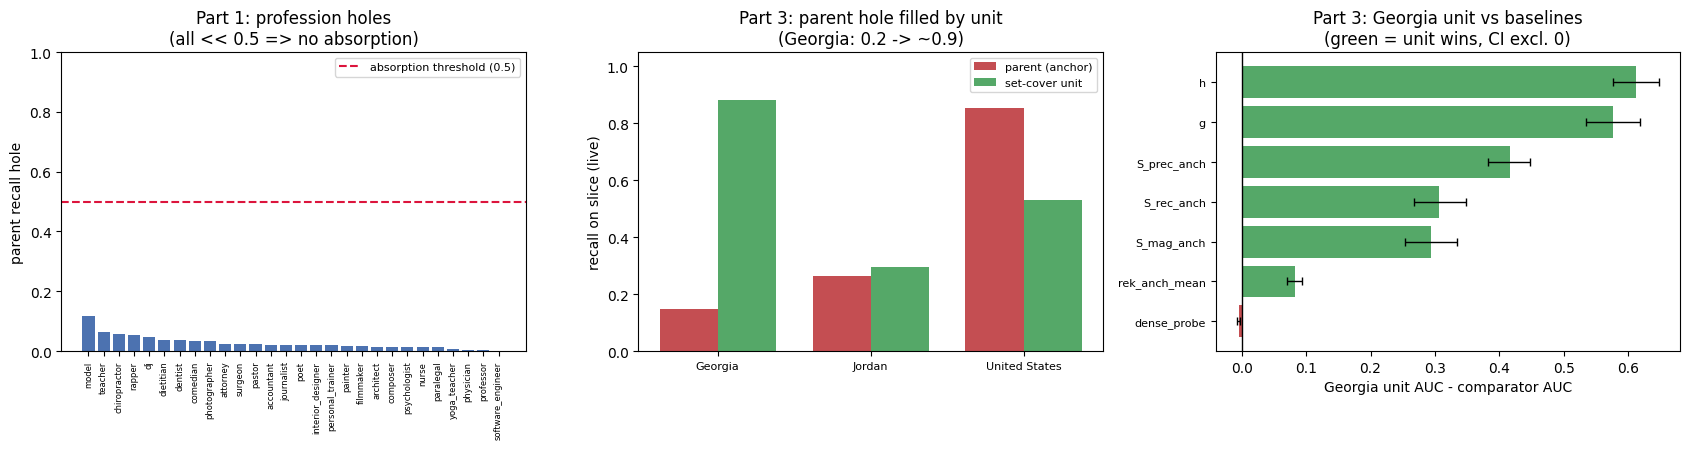

Overall verdict: absorption_remains_narrow | professions: uniform_high_parent_recall_no_absorption


In [15]:
# --- Summary visualization ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# Panel 1: profession parent holes vs absorption threshold
hd = hole_df.sort_values("parent_hole", ascending=False)
axes[0].bar(range(len(hd)), hd["parent_hole"], color="#4C72B0")
axes[0].axhline(HOLE_THRESHOLD, color="crimson", ls="--", lw=1.5,
                label=f"absorption threshold ({HOLE_THRESHOLD})")
axes[0].set_xticks(range(len(hd)))
axes[0].set_xticklabels(hd["profession"], rotation=90, fontsize=6)
axes[0].set_ylabel("parent recall hole")
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Part 1: profession holes\n(all << 0.5 => no absorption)")
axes[0].legend(fontsize=8)

# Panel 2: parent (anchor) recall vs unit recall per country (live recomputation)
x = np.arange(len(COUNTRIES)); w = 0.38
anchor_rec = [float(recall_df.loc[recall_df.country == c, "anchor"].iloc[0]) for c in COUNTRIES]
unit_rec   = [float(recall_df.loc[recall_df.country == c, "unit"].iloc[0]) for c in COUNTRIES]
axes[1].bar(x - w/2, anchor_rec, w, label="parent (anchor)", color="#C44E52")
axes[1].bar(x + w/2, unit_rec,   w, label="set-cover unit", color="#55A868")
axes[1].set_xticks(x); axes[1].set_xticklabels(COUNTRIES, fontsize=8)
axes[1].set_ylabel("recall on slice (live)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Part 3: parent hole filled by unit\n(Georgia: 0.2 -> ~0.9)")
axes[1].legend(fontsize=8)

# Panel 3: Georgia AUC-diff (unit minus baseline) with CIs
adp = ad_df.sort_values("auc_diff")
yerr = np.array([adp["auc_diff"] - adp["ci_lo"], adp["ci_hi"] - adp["auc_diff"]])
colors = ["#55A868" if w_ else "#C44E52" for w_ in adp["unit_wins"]]
axes[2].barh(range(len(adp)), adp["auc_diff"], xerr=yerr, color=colors,
             error_kw=dict(ecolor="black", lw=1, capsize=3))
axes[2].axvline(0, color="black", lw=1)
axes[2].set_yticks(range(len(adp))); axes[2].set_yticklabels(adp["comparator"], fontsize=8)
axes[2].set_xlabel("Georgia unit AUC - comparator AUC")
axes[2].set_title("Part 3: Georgia unit vs baselines\n(green = unit wins, CI excl. 0)")

plt.tight_layout()
plt.savefig("m7_summary.png", dpi=110, bbox_inches="tight")
plt.show()
print("Overall verdict:", verdict["verdict"],
      "| professions:", prof["professions_verdict"])